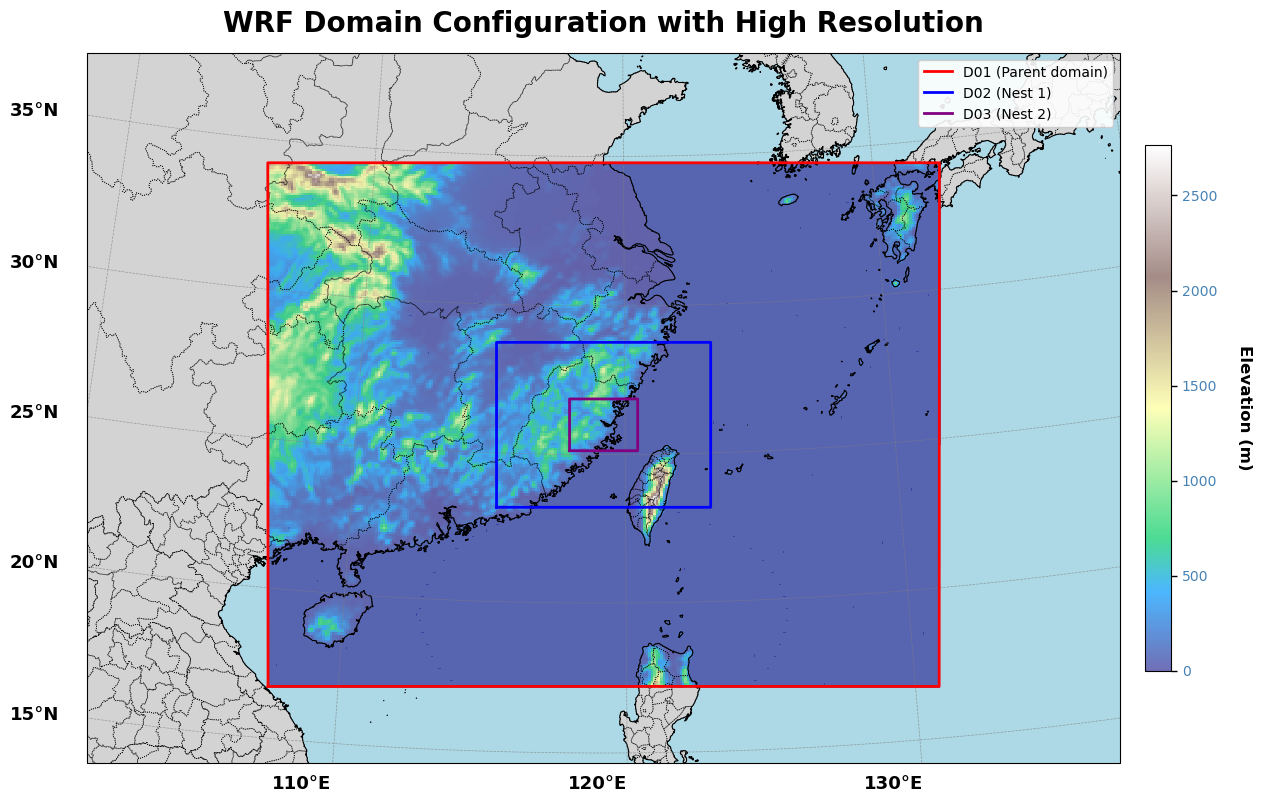

In [22]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 读取地理数据文件
d01 = xr.open_dataset('E:/000_FuJian/geo_em/geo_em.d01.nc')
d02 = xr.open_dataset('E:/000_FuJian/geo_em/geo_em.d02.nc')
d03 = xr.open_dataset('E:/000_FuJian/geo_em/geo_em.d03.nc')

# 创建Lambert投影
proj = ccrs.LambertConformal(
    central_longitude=d01.STAND_LON.item(),
    central_latitude=d01.CEN_LAT.item(),
    standard_parallels=(d01.TRUELAT1.item(), d01.TRUELAT2.item())
)

# 创建图形
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection=proj)

# 添加高分辨率地理特征
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':', linewidth=0.6, zorder=2)
ax.add_feature(cfeature.STATES.with_scale('10m'), linestyle=':', linewidth=0.6, zorder=2)

# 绘制地形高程
terrain = d01.HGT_M[0,:,:]
mesh = ax.pcolormesh(
    d01.XLONG_M[0], 
    d01.XLAT_M[0], 
    terrain,
    cmap='terrain',
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    vmin=0,
    shading='auto',
    zorder=1
)

# 定义域边界绘制函数
def plot_domain_box(ds, color, label):
    x = [
        ds.XLONG_M[0,0,0].item(), 
        ds.XLONG_M[0,0,-1].item(),
        ds.XLONG_M[0,-1,-1].item(), 
        ds.XLONG_M[0,-1,0].item(),
        ds.XLONG_M[0,0,0].item()
    ]
    y = [
        ds.XLAT_M[0,0,0].item(),
        ds.XLAT_M[0,0,-1].item(),
        ds.XLAT_M[0,-1,-1].item(),
        ds.XLAT_M[0,-1,0].item(),
        ds.XLAT_M[0,0,0].item()
    ]
    ax.plot(x, y, color=color, linewidth=2, 
            transform=ccrs.PlateCarree(),
            label=label, zorder=3)

# 绘制三个域边界
plot_domain_box(d01, 'red', 'D01 (Parent domain)')
plot_domain_box(d02, 'blue', 'D02 (Nest 1)')
plot_domain_box(d03, 'purple', 'D03 (Nest 2)')

# 设置绘图范围
def calc_padding(ds):
    lon_span = ds.XLONG_M.max().item() - ds.XLONG_M.min().item()
    lat_span = ds.XLAT_M.max().item() - ds.XLAT_M.min().item()
    return max(lon_span * 0.15, 2), max(lat_span * 0.15, 1)

lon_pad, lat_pad = calc_padding(d01)
ax.set_extent([
    d01.XLONG_M.min().item() - lon_pad,
    d01.XLONG_M.max().item() + lon_pad,
    d01.XLAT_M.min().item() - lat_pad,
    d01.XLAT_M.max().item() + lat_pad
], crs=ccrs.PlateCarree())

# 配置经纬网格
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.7,
    linestyle='--',
    zorder=4,
    x_inline=False,
    y_inline=False,
    xpadding=15,
    ypadding=20
)

# 设置经纬度标签样式
xlabel_style = {
    'fontsize': 13,
    'color': 'black',
    'weight': 'semibold',
    'rotation': 0, 
}
ylabel_style = {
    'fontsize': 13,
    'color': 'black',
    'weight': 'semibold',
    'rotation': 0, 
}
gl.xlabel_style = xlabel_style
gl.ylabel_style = ylabel_style
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

# 添加颜色条
cbar = plt.colorbar(mesh, ax=ax, shrink=0.6, pad=0.02)
cbar_label_style = {
    'label': 'Elevation (m)',
    'rotation': 270,
    'labelpad': 25,
    'fontsize': 12,
    'color': 'black',
    'weight': 'bold'
}
cbar.set_label(**cbar_label_style)

# 设置颜色条刻度样式
cbar.ax.tick_params(
    labelsize=10,
    labelcolor='steelblue',
    direction='out',
    length=4,
    width=1
)

# 添加图例和标题
ax.legend(loc='upper right', framealpha=0.9)
plt.title('WRF Domain Configuration with High Resolution', 
          fontsize=20, pad=15, weight='semibold')

# 调整布局边距
plt.subplots_adjust(bottom=0.15, left=0.12, right=0.95)
'''
# 保存高分辨率图像
plt.savefig('wrf_domains_high_res.png', 
           dpi=400, 
           bbox_inches='tight',
           facecolor='white')
'''
plt.show()
